## **Library Imports - 15-minute horizon**

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging
from scipy import stats
import seaborn as sns
from scipy.stats import ks_2samp
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import time
import joblib
import statsmodels.api as sm

# Add the parent directory to Python's path
sys.path.append(os.path.abspath('..'))

from sklearn.preprocessing import StandardScaler

# Import your custom modules
import src.config as config
from src.model_prep_tools import create_multivariate_sequences, flatten_for_ml
from src.model_architectures import run_power_lstm, run_vanilla_transformer, run_keras_patchtst, run_chronos_univariate, run_chronos2_multivariate
from src.ml_baselines import xgboost_implementation, rf_implementation, run_daily_naive
from src.evaluation_utils import save_experiment_results, plot_predictions, calculate_metrics, plot_hourly_error_heatmap, plot_uncertainty_bounds, run_all_residual_diagnostics, evaluate_statistical_significance

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')


# 15-MINUTE HORIZON CONFIGURATION

HORIZON_NAME = "15_min"
HORIZON_STEPS = 96
SEQ_LENGTH = 96
RANDOM_SEED = 2026

# Lock all environments using our centralized config tool!
config.set_global_seeds(RANDOM_SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Global random seeds set to 2026


### **Data Load, Split, fit scaler and MIMO sequence**

In [12]:
# LOAD DATA
df_master = pd.read_parquet('../data/processed/nanogrid_15min_features.parquet')
TARGET_COL = config.TARGET_COL

# DEEP LEARNING PREP (Needs 3D continuous sequences)
dl_features = [TARGET_COL] + config.FEATURE_SETS["DEEP_LEARNING"]
df_dl = df_master[dl_features].copy()
dl_target_idx = df_dl.columns.get_loc(TARGET_COL)

# TREE PREP (Needs current snapshot + engineered lags)
tree_features = [TARGET_COL] + config.FEATURE_SETS["TREE_MODELS"]
df_tree = df_master[tree_features].copy()

# Split Indices (Strictly Chronological 70/10/20)
total_rows = len(df_master)
train_idx = int(total_rows * 0.70)
val_idx = int(total_rows * 0.80)

print(f"Master Dataset: {df_master.shape}")
print(f"DL Matrix Features: {len(dl_features)}")
print(f"Tree Matrix Features: {len(tree_features)}")

Master Dataset: (53225, 22)
DL Matrix Features: 18
Tree Matrix Features: 18


In [13]:
SEQ_LENGTH = config.SEQUENCE_LENGTH
HORIZON_STEPS = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

# DEEP LEARNING SCALING & SEQUENCES
dl_scaler_feat = StandardScaler()
dl_scaler_targ = StandardScaler()
df_dl_scaled = df_dl.copy()

dl_feat_cols = [c for c in df_dl.columns if c != TARGET_COL]

# Fit strictly on train, Transform the entire column safely
dl_scaler_targ.fit(df_dl.iloc[:train_idx][[TARGET_COL]])
df_dl_scaled[TARGET_COL] = dl_scaler_targ.transform(df_dl[[TARGET_COL]])

dl_scaler_feat.fit(df_dl.iloc[:train_idx][dl_feat_cols])
df_dl_scaled[dl_feat_cols] = dl_scaler_feat.transform(df_dl[dl_feat_cols])

# Generate 3D Sequences
X_train_3d, y_train = create_multivariate_sequences(df_dl_scaled.iloc[:train_idx].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)
X_val_3d, y_val     = create_multivariate_sequences(df_dl_scaled.iloc[train_idx:val_idx].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)
X_test_3d, y_test   = create_multivariate_sequences(df_dl_scaled.iloc[val_idx:].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)


# TREE SCALING & T-ZERO SLICE
tree_scaler_feat = StandardScaler()
df_tree_scaled = df_tree.copy()
tree_feat_cols = [c for c in df_tree.columns if c != TARGET_COL]

# Fit strictly on train, Transform the entire column safely
tree_scaler_feat.fit(df_tree.iloc[:train_idx][tree_feat_cols])
df_tree_scaled[tree_feat_cols] = tree_scaler_feat.transform(df_tree[tree_feat_cols])

# Generate sequences to match y_targets perfectly, but only keep the T=0 row
X_train_tree_temp, _ = create_multivariate_sequences(df_tree_scaled.iloc[:train_idx].values, 0, SEQ_LENGTH, HORIZON_STEPS)
X_val_tree_temp, _   = create_multivariate_sequences(df_tree_scaled.iloc[train_idx:val_idx].values, 0, SEQ_LENGTH, HORIZON_STEPS)
X_test_tree_temp, _  = create_multivariate_sequences(df_tree_scaled.iloc[val_idx:].values, 0, SEQ_LENGTH, HORIZON_STEPS)

# The T-Zero Slice
X_train_tree = X_train_tree_temp[:, -1, :]
X_val_tree   = X_val_tree_temp[:, -1, :]
X_test_tree  = X_test_tree_temp[:, -1, :]

print(f"Deep Learning Inputs (3D): Train {X_train_3d.shape} | Val {X_val_3d.shape} | Test {X_test_3d.shape}")
print(f"Tree Inputs (2D): Train {X_train_tree.shape} | Val {X_val_tree.shape} | Test {X_test_tree.shape}")
print(f"Universal Targets (y): Train {y_train.shape} | Val {y_val.shape} | Test {y_test.shape}")

# Lock seeds
config.set_global_seeds(config.RANDOM_SEED)

# Validate the configuration!
config.validate_config()

Deep Learning Inputs (3D): Train (37066, 96, 18) | Val (5132, 96, 18) | Test (10454, 96, 18)
Tree Inputs (2D): Train (37066, 18) | Val (5132, 18) | Test (10454, 18)
Universal Targets (y): Train (37066, 96) | Val (5132, 96) | Test (10454, 96)
Global random seeds set to 2026
Configuration validation passed


In [14]:
if 'horizon_metrics' not in locals():
    horizon_metrics = []

# True to retrain
# False to load saved weights
TRAIN_FROM_SCRATCH = True

### **Naive Baseline** 
Predicts that tomorrow's 96-step sequence will be exactly identical 
    to the sequence from 24 hours (96 steps) ago.

Daily_Naive_Baseline artifacts successfully saved to ../results/15_min/Daily_Naive_Baseline/


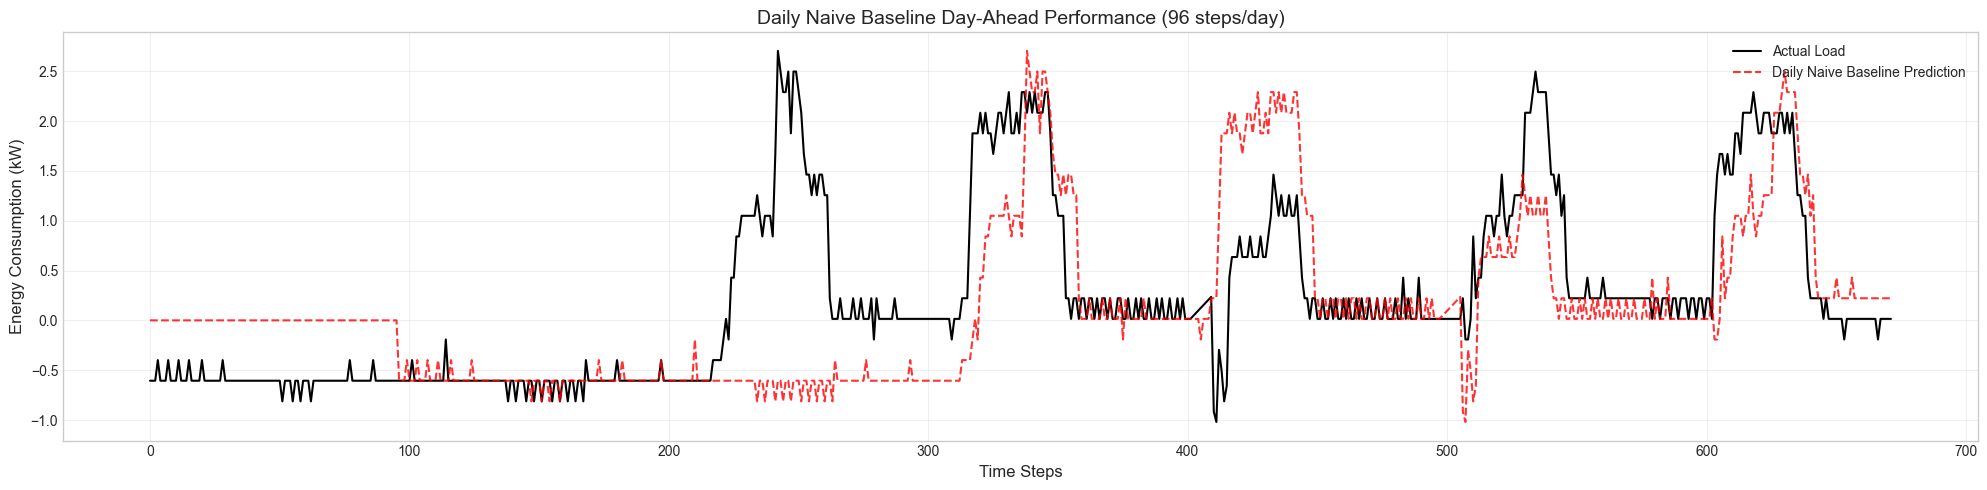

In [15]:
current_horizon = config.HORIZON_STEPS[config.ACTIVE_HORIZON]
start_time = time.time()
naive_predictions = run_daily_naive(y_test, horizon=current_horizon)
exec_time = time.time() - start_time

naive_metrics = calculate_metrics(
    y_true=y_test, 
    y_pred=naive_predictions, 
    model_name="Daily_Naive_Baseline", 
    execution_time=exec_time,
    horizon=current_horizon, 
    y_train=y_train 
)

naive_results_dict = {
    "model": "Daily_Naive",
    "predictions": naive_predictions,
    "y_test_real": y_test,
    "metrics": naive_metrics
}

save_experiment_results(
    results_dict=naive_results_dict, 
    model_name="Daily_Naive_Baseline", 
    horizon_name=config.ACTIVE_HORIZON, 
    y_test=y_test, 
    horizon=current_horizon
)
horizon_metrics.append(naive_metrics)

plot_predictions(
    y_true=y_test, 
    y_pred=naive_predictions, 
    model_name="Daily Naive Baseline", 
    horizon=current_horizon,
    num_steps=current_horizon * 7 # Plot 3 days to see the 24h lag effect
)

### **Tree-Based Baselines**
Utilizing Optuna Tuning


RUNNING XGBOOST_MAE (15_min) | Horizon: 96
Performing Smart Flattening (Feature Reduction)
Reduced feature columns shape to 113


[I 2026-06-08 12:15:18,267] A new study created in memory with name: no-name-85261bf9-dcdd-4525-9d83-ce967abbc9f8


Identifying best XGBoost hyperparameters using Optuna (Optimizing for MAE)


[I 2026-06-08 12:16:34,837] Trial 0 finished with value: 0.2567101142695784 and parameters: {'n_estimators': 122, 'max_depth': 6, 'learning_rate': 0.19362576732468723, 'subsample': 0.6355596086592517, 'colsample_bytree': 0.8437869579040544}. Best is trial 0 with value: 0.2567101142695784.
[I 2026-06-08 12:17:58,329] Trial 1 finished with value: 0.24933629235558033 and parameters: {'n_estimators': 199, 'max_depth': 4, 'learning_rate': 0.17696086757218202, 'subsample': 0.8233000459463433, 'colsample_bytree': 0.9349688405427283}. Best is trial 1 with value: 0.24933629235558033.
[I 2026-06-08 12:19:02,945] Trial 2 finished with value: 0.23738043560268507 and parameters: {'n_estimators': 130, 'max_depth': 5, 'learning_rate': 0.07536333057798665, 'subsample': 0.9576353844058, 'colsample_bytree': 0.7144525308138557}. Best is trial 2 with value: 0.23738043560268507.
[I 2026-06-08 12:20:36,706] Trial 3 finished with value: 0.2460370737885551 and parameters: {'n_estimators': 144, 'max_depth': 6,

Training Final XGBoost Model on Full Combined Dataset
Model successfully cached at ../results/15_min/XGBoost_MAE/xgboost_mae_model.joblib


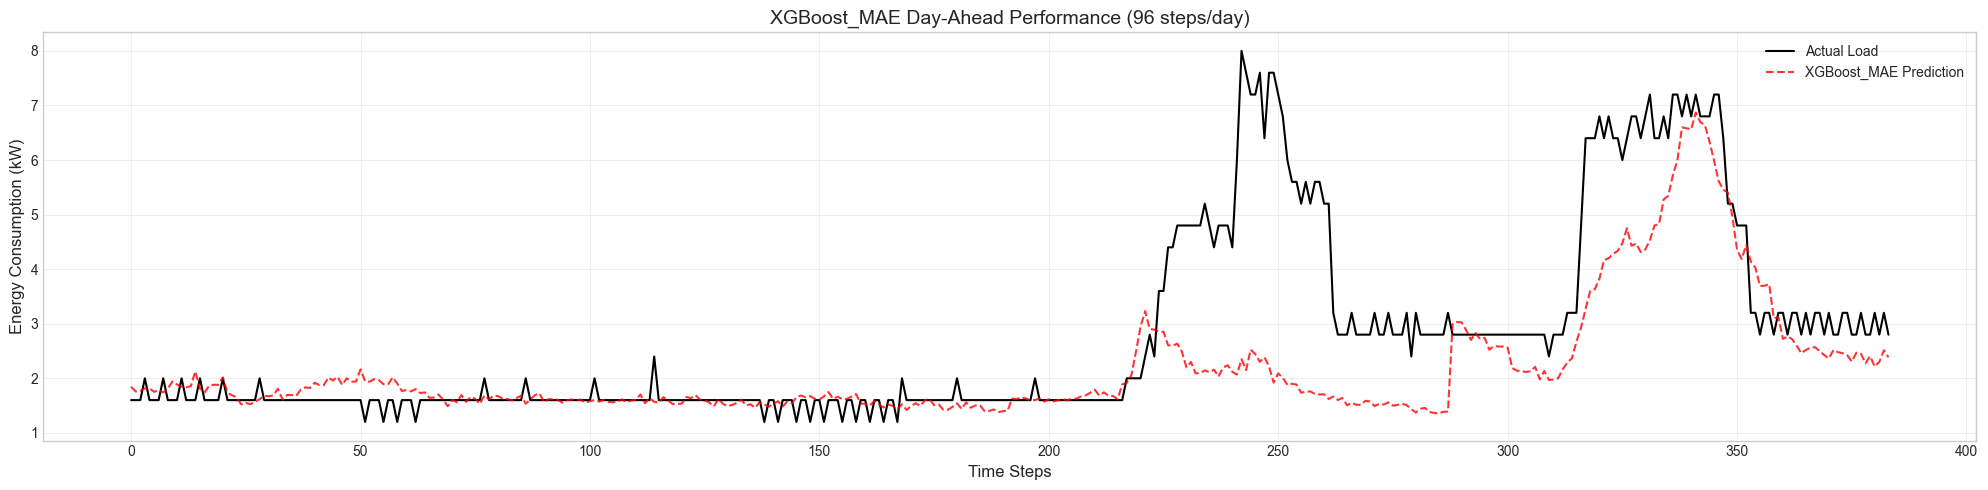

XGBoost_MAE artifacts successfully saved to ../results/15_min/XGBoost_MAE/

RUNNING XGBOOST_RMSE (15_min) | Horizon: 96
Performing Smart Flattening (Feature Reduction)
Reduced feature columns shape to 113
Identifying best XGBoost hyperparameters using Optuna (Optimizing for RMSE)


[I 2026-06-08 12:40:10,783] A new study created in memory with name: no-name-2b549684-c31b-466b-87e0-86da839d9b3f
[I 2026-06-08 12:41:02,610] Trial 0 finished with value: 0.4769584040723924 and parameters: {'n_estimators': 122, 'max_depth': 6, 'learning_rate': 0.19362576732468723, 'subsample': 0.6355596086592517, 'colsample_bytree': 0.8437869579040544}. Best is trial 0 with value: 0.4769584040723924.
[I 2026-06-08 12:41:45,312] Trial 1 finished with value: 0.48007375506449196 and parameters: {'n_estimators': 199, 'max_depth': 4, 'learning_rate': 0.17696086757218202, 'subsample': 0.8233000459463433, 'colsample_bytree': 0.9349688405427283}. Best is trial 0 with value: 0.4769584040723924.
[I 2026-06-08 12:42:21,810] Trial 2 finished with value: 0.4380403534619673 and parameters: {'n_estimators': 130, 'max_depth': 5, 'learning_rate': 0.07536333057798665, 'subsample': 0.9576353844058, 'colsample_bytree': 0.7144525308138557}. Best is trial 2 with value: 0.4380403534619673.
[I 2026-06-08 12:4

Training Final XGBoost Model on Full Combined Dataset
Model successfully cached at ../results/15_min/XGBoost_RMSE/xgboost_rmse_model.joblib


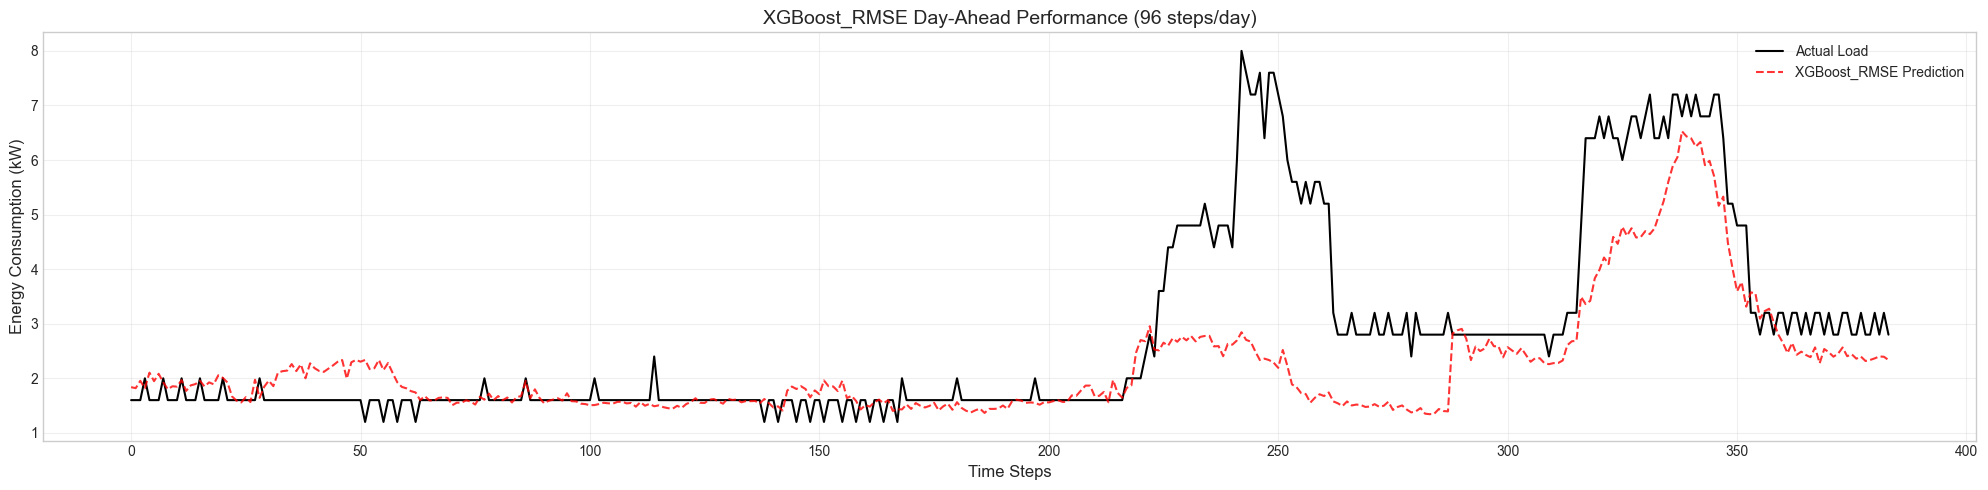

XGBoost_RMSE artifacts successfully saved to ../results/15_min/XGBoost_RMSE/


In [28]:
# XGBoost

xgboost_experiments = ["MAE", "RMSE"]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for metric in xgboost_experiments:
    results = xgboost_implementation(
        X_train=X_train_3d, y_train=y_train,
        X_val=X_val_3d, y_val=y_val,
        X_test=X_test_3d, y_test=y_test,
        horizon_name=config.ACTIVE_HORIZON,
        y_train_full=y_train,
        target_scaler=dl_scaler_targ,
        target_feature_idx=dl_target_idx,
        optimization_metric=metric,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    horizon_metrics.append(results["metrics"])

    save_experiment_results(
        results_dict=results, 
        model_name=f"XGBoost_{metric}", 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results['y_test_real'], 
        horizon=horizon_val
    )

    horizon_metrics.append(results["metrics"])


 RUNNING RANDOM_FOREST (15_min) | Horizon: 96
 -> Performing Smart Flattening (Domain Knowledge Feature Reduction)
    Reduced feature columns shape to 113
Identifying best Random Forest hyperparameters using Optuna


[I 2026-06-08 13:02:25,818] A new study created in memory with name: no-name-d11e375d-7d80-4306-b98b-302a4bd45ebe
[I 2026-06-08 13:02:46,348] Trial 0 finished with value: 0.2924437182545702 and parameters: {'n_estimators': 144, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 0.6355029017761271}. Best is trial 0 with value: 0.2924437182545702.
[I 2026-06-08 13:03:34,847] Trial 1 finished with value: 0.2992735720148924 and parameters: {'n_estimators': 298, 'max_depth': 9, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 0.8482606279330327}. Best is trial 0 with value: 0.2924437182545702.
[I 2026-06-08 13:03:47,705] Trial 2 finished with value: 0.27429769617164684 and parameters: {'n_estimators': 160, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 0.33372257189899684}. Best is trial 2 with value: 0.27429769617164684.
[I 2026-06-08 13:04:32,806] Trial 3 finished with value: 0.3010194251859002 and parameters: {

Training Final Multi-Output Random Forest on Full Dataset
Model successfully cached at ../results/15_min/Random_Forest/random_forest_model.joblib


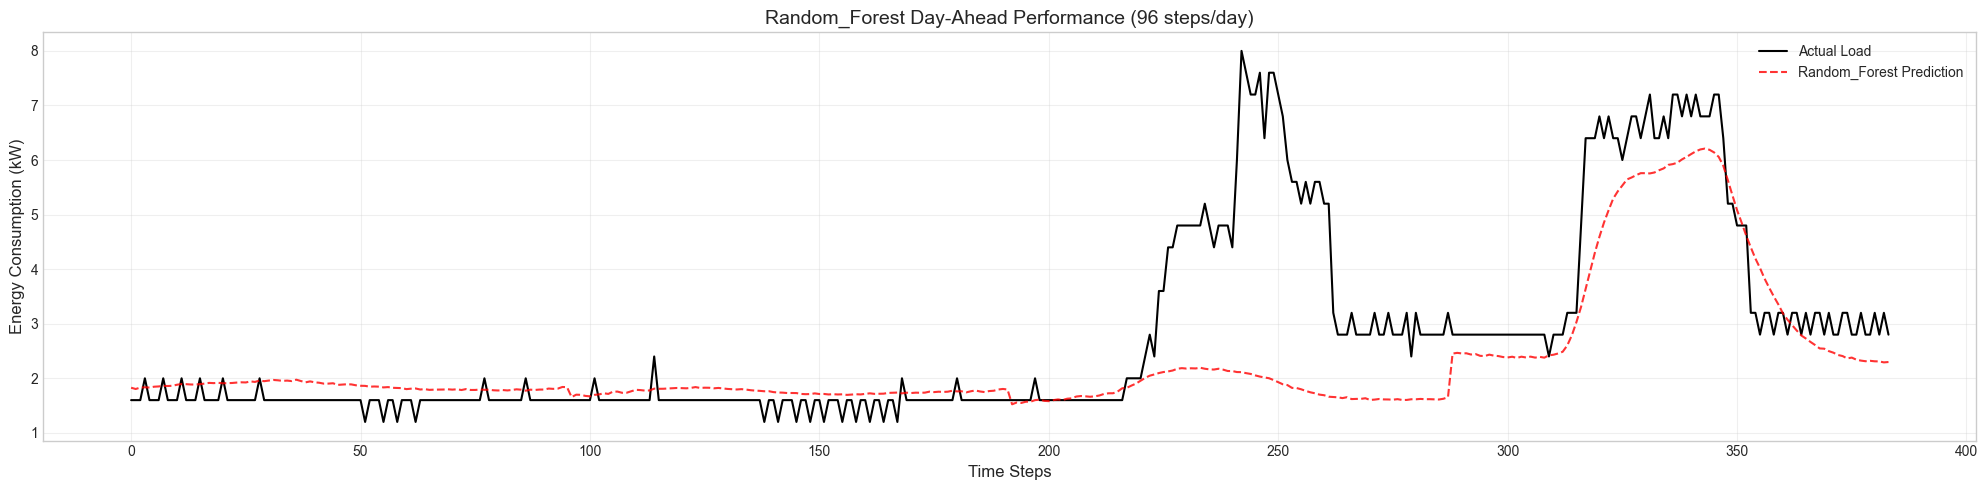

Random_Forest artifacts successfully saved to ../results/15_min/Random_Forest/


In [29]:
# Random Forest

horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

results_rf = rf_implementation(
    X_train=X_train_3d, y_train=y_train,
    X_val=X_val_3d, y_val=y_val,
    X_test=X_test_3d, y_test=y_test,
    horizon_name=config.ACTIVE_HORIZON,
    y_train_full=y_train,
    target_scaler=dl_scaler_targ,
    target_feature_idx=dl_target_idx,
    train_from_scratch=TRAIN_FROM_SCRATCH
)

save_experiment_results(
    results_dict=results_rf, 
    model_name="Random_Forest", 
    horizon_name=config.ACTIVE_HORIZON, 
    y_test=results_rf['y_test_real'], 
    horizon=horizon_val
)

horizon_metrics.append(results_rf["metrics"])

### 7-Day plots for tree models:


Loading XGBoost_MAE from cache...


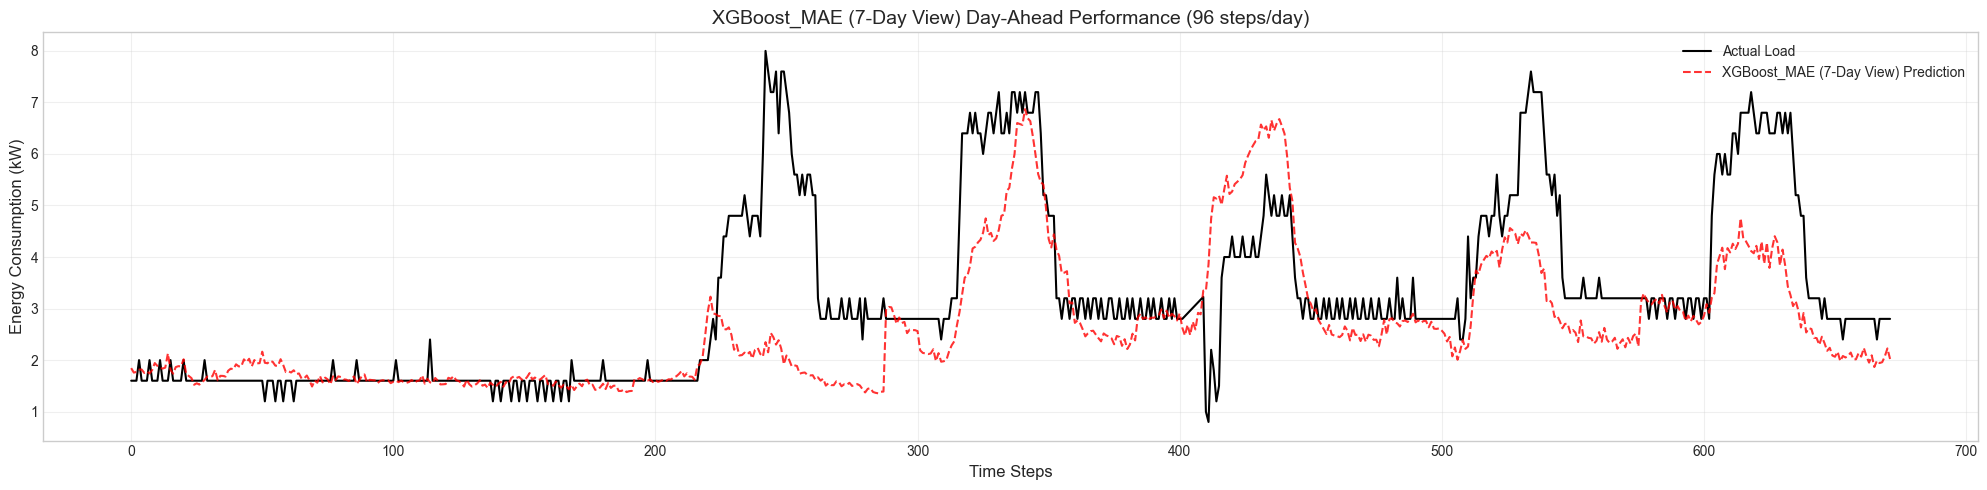


Loading XGBoost_RMSE from cache...


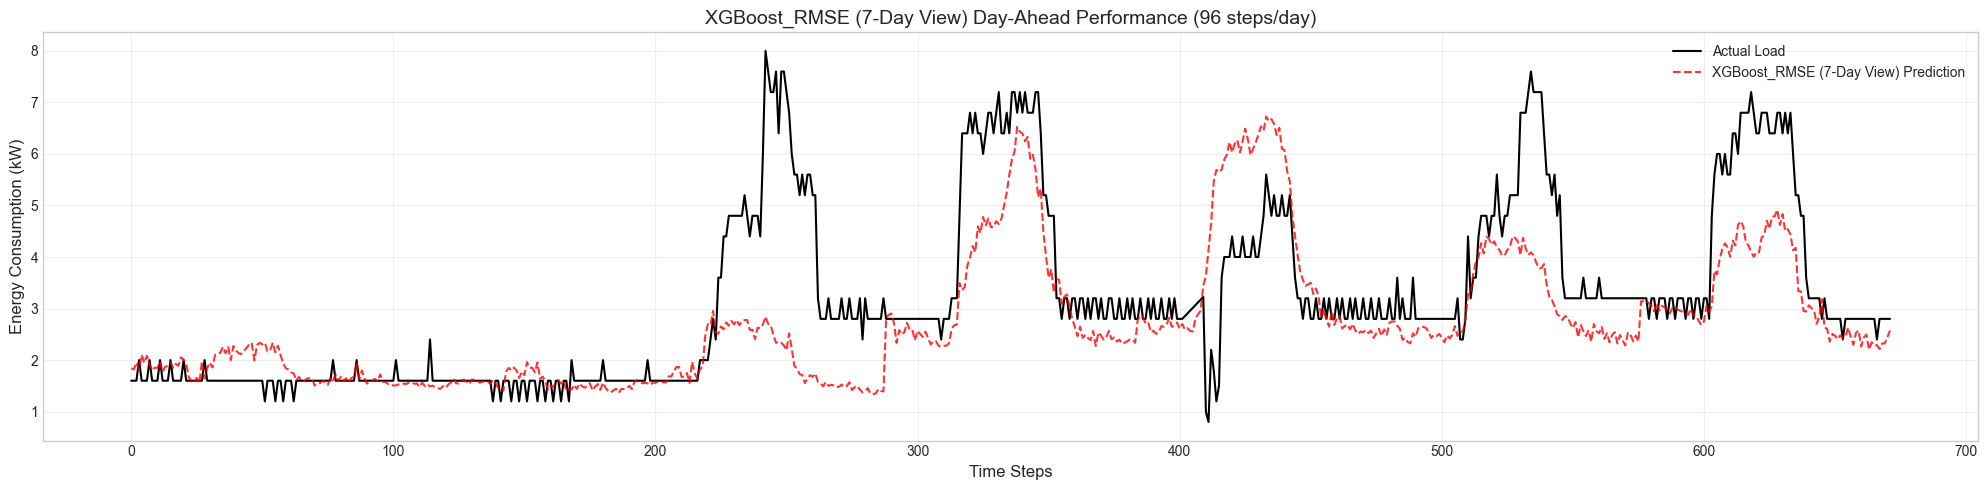


Loading Random_Forest from cache...


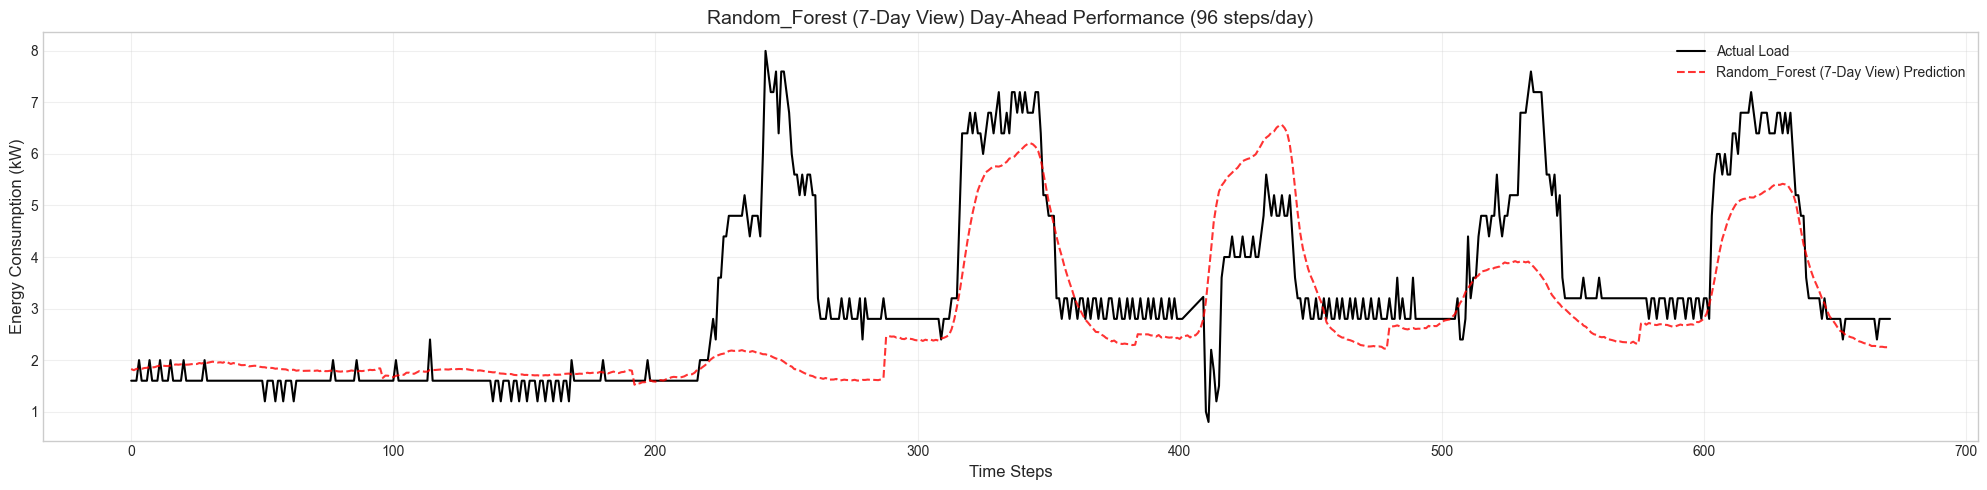

In [31]:
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

# Recreate the Smart Flattening for the Test Sets
def smart_flatten(X_3d, target_idx=0):
    hist_target = X_3d[:, :, target_idx] 
    covariate_indices = [i for i in range(X_3d.shape[2]) if i != target_idx]
    current_state = X_3d[:, -1, covariate_indices] 
    return np.hstack((hist_target, current_state))

# Flatten the standard test set
X_test_flat_smart = smart_flatten(X_test_3d, dl_target_idx)

# Define exactly what is on your hard drive right now
tree_models = [
    {"folder": "XGBoost_MAE", "file": "xgboost_mae_model.joblib"},
    {"folder": "XGBoost_RMSE", "file": "xgboost_rmse_model.joblib"},
    {"folder": "Random_Forest", "file": "random_forest_model.joblib"}
]

# Loop, Load, Predict and Plot
for model_info in tree_models:
    folder_name = model_info["folder"]
    file_name = model_info["file"]
    
    # Build the exact path based on your screenshot
    model_save_path = f"../results/{config.ACTIVE_HORIZON}/{folder_name}/{file_name}"
    
    try:
        print(f"\nLoading {folder_name} from cache...")
        cached_model = joblib.load(model_save_path)
        
        # Generate Predictions
        test_preds = cached_model.predict(X_test_flat_smart)
        
        # Inverse Scale back to kW
        orig_shape = test_preds.shape
        test_preds_unscaled = dl_scaler_targ.inverse_transform(test_preds.reshape(-1, 1)).reshape(orig_shape)
        y_test_unscaled = dl_scaler_targ.inverse_transform(y_test.reshape(-1, 1)).reshape(orig_shape)
        
        # Plot 7 Days
        plot_predictions(
            y_true=y_test_unscaled, 
            y_pred=test_preds_unscaled, 
            model_name=f"{folder_name} (7-Day View)", 
            horizon=horizon_val,
            num_steps=horizon_val * 7
        )
    except FileNotFoundError:
        print(f"Could not find cached model at {model_save_path}.")

### **Deep Learning Models:**


 Running: Power_LSTM_Standard_Capacity

 RUNNING POWER_LSTM (15_min) | Horizon: 96
Training LSTM for 96 steps
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - loss: 0.0178 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - loss: 0.0129 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - loss: 0.0120 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - loss: 0.0115 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 5/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - loss: 0.0112 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - loss: 0.0110 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - loss: 0.0108 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 8/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - loss: 0.0107 - val_loss: 0.0137 -

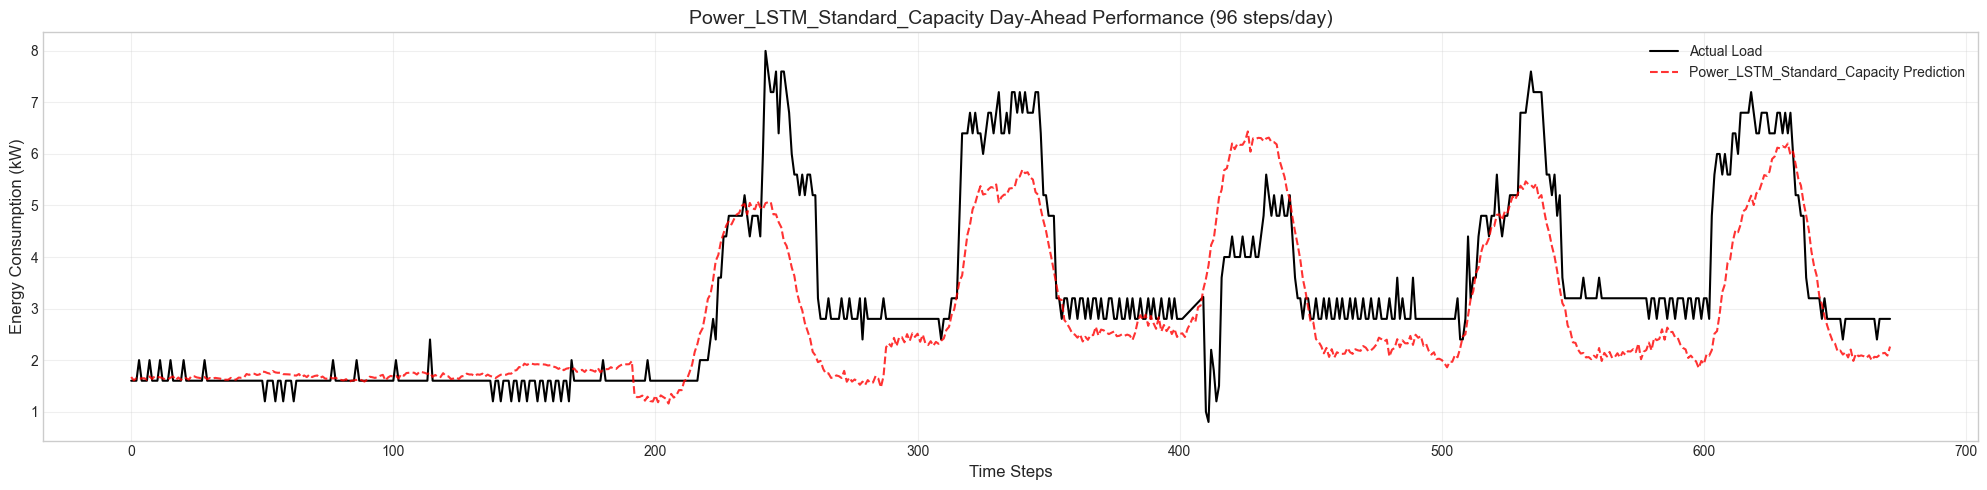


 Running: Power_LSTM_High_Capacity

 RUNNING POWER_LSTM (15_min) | Horizon: 96
Training LSTM for 96 steps
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 65s 54ms/step - loss: 0.0168 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 64s 55ms/step - loss: 0.0123 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 63s 55ms/step - loss: 0.0113 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 64s 55ms/step - loss: 0.0109 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 5/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 64s 55ms/step - loss: 0.0106 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 63s 55ms/step - loss: 0.0103 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 64s 55ms/step - loss: 0.0101 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 8/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 64s 56ms/step - loss: 0.0100 - val_loss: 0.0130 - lea

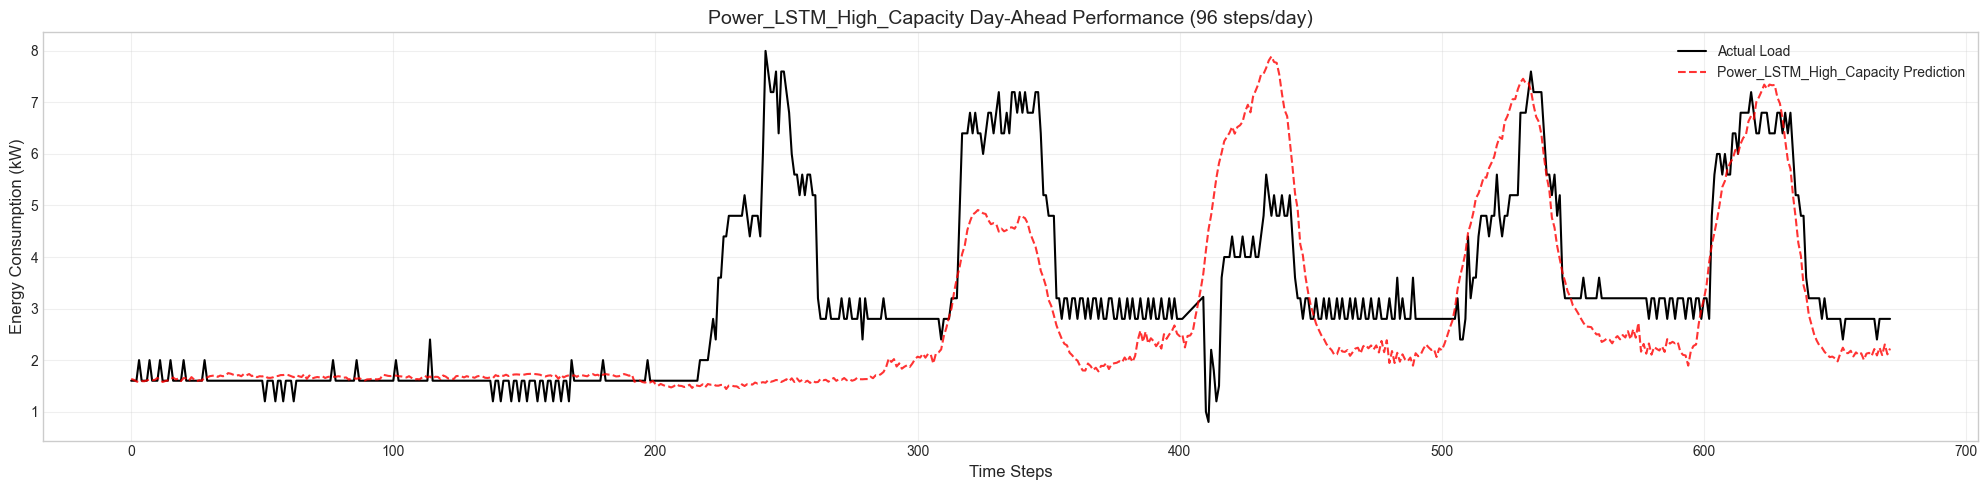

In [ ]:
# LSTM experiments
original_lstm_config = config.LSTM_CONFIG.copy()

lstm_experiments = [
    {
        "name": "Power_LSTM_Standard_Capacity", 
        "hidden_units": [64, 32], 
        "dropout": 0.2
    },
    {
        "name": "Power_LSTM_High_Capacity", 
        "hidden_units": [128, 64], 
        "dropout": 0.4  # Doubling capacity requires doubling regularization
    }
]

epochs = config.TRAINING_PARAMS["epochs"]
batch_size = config.TRAINING_PARAMS["batch_size"]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for exp in lstm_experiments:
    exp_name = exp["name"]
    print(f"\n Running: {exp_name}")
    
    # Dynamically inject the experimental parameters into the config
    config.LSTM_CONFIG["hidden_units"] = exp["hidden_units"]
    config.LSTM_CONFIG["dropout"] = exp["dropout"]
    
    # Train or Load Model
    results = run_power_lstm(
        X_train=X_train_3d, y_train=y_train, 
        X_val=X_val_3d, y_val=y_val, 
        X_test=X_test_3d, y_test=y_test, 
        horizon_name=config.ACTIVE_HORIZON, 
        horizon=horizon_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        random_state=config.RANDOM_SEED, 
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Calculate Metrics
    metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        execution_time=results['execution_time'], 
        horizon=horizon_val, 
        y_train=y_train
    )
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results, 
        model_name=exp_name, 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results['y_test_real'], 
        horizon=horizon_val
    )
    
    horizon_metrics.append(metrics)
    print(f" {exp_name} added to leaderboard! (MASE: {metrics['MASE']:.3f})")
    
    # Plot the 7-day trajectory to capture weekend dynamics
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        horizon=horizon_val,
        num_steps=horizon_val * 7 
    )

# Restore original config
config.LSTM_CONFIG = original_lstm_config

In [ ]:
# LSTM experiment
original_lstm_config = config.LSTM_CONFIG.copy()
config.LSTM_CONFIG["hidden_units"] = [128, 96] 
config.LSTM_CONFIG["loss"] = "mse"
config.LSTM_CONFIG["dropout"] = 0.2
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]
model_name = "LSTM_Wide_MSE"

# Train/Load the Model
results_lstm = run_power_lstm(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=config.ACTIVE_HORIZON,
    horizon=horizon_val,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    target_scaler=dl_scaler_targ,
    train_from_scratch=TRAIN_FROM_SCRATCH
)

# Save experiments
save_experiment_results(
    results_dict=results_lstm, 
    model_name=model_name, 
    horizon_name=config.ACTIVE_HORIZON, 
    y_test=results_lstm['y_test_real'], 
    horizon=horizon_val
)

# Evaluation Metrics Calculation
if 'metrics' not in results_lstm:
    # Inverse Scale the training data for the MASE calculation baseline
    if dl_scaler_targ is not None:
        y_train_unscaled = dl_scaler_targ.inverse_transform(y_train.reshape(-1, 1)).flatten()
    else:
        y_train_unscaled = y_train.flatten()
        
    metrics = calculate_metrics(
        y_true=results_lstm['y_test_real'], 
        y_pred=results_lstm['predictions'], 
        model_name=model_name, 
        execution_time=results_lstm['execution_time'], 
        horizon=horizon_val, 
        y_train=y_train_unscaled
    )
    results_lstm['metrics'] = metrics
else:
    metrics = results_lstm['metrics']

# Append to Leaderboard
horizon_metrics.append(metrics)

# Plot predictions
plot_predictions(
    y_true=results_lstm['y_test_real'], 
    y_pred=results_lstm['predictions'], 
    model_name=f"{model_name} (7-Day View)", 
    horizon=horizon_val,
    num_steps=horizon_val * 7
)

# Restore config
config.LSTM_CONFIG = original_lstm_config

Generating 192-step (2-Day) matrices for deep context testing
1-Day Test Targets (y): 10454
2-Day Test Targets (y): 10358 (Shorter due to warmup)

Running: Vanilla_Transformer_1Day_Context (Sequence: 96)

RUNNING VANILLA TRANSFORMER (15_min) | Horizon: 96
Training Vanilla Transformer for 96 steps
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - loss: 0.0212 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - loss: 0.0160 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - loss: 0.0148 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - loss: 0.0142 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 5/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - loss: 0.0138 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - loss: 0.0133 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 7/50
1159/11

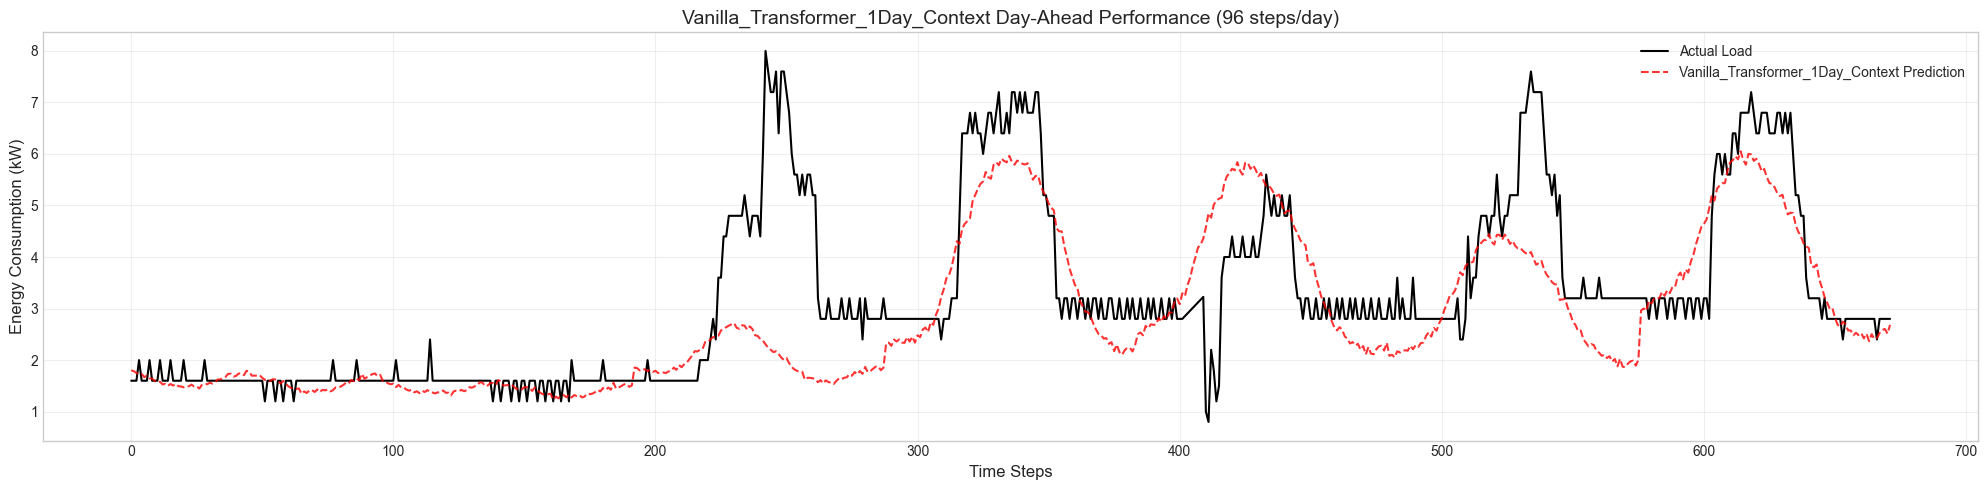


Running: Vanilla_Transformer_2Day_Context (Sequence: 192)

RUNNING VANILLA TRANSFORMER (15_min) | Horizon: 96
Training Vanilla Transformer for 96 steps
Epoch 1/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 80s 67ms/step - loss: 0.0276 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 2/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 78s 67ms/step - loss: 0.0249 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 3/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - loss: 0.0240 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 4/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - loss: 0.0236 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 5/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 78s 68ms/step - loss: 0.0233 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 6/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 78s 67ms/step - loss: 0.0231 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 7/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 79s 68ms/step - loss: 0.0229 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 8/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 78s 67m

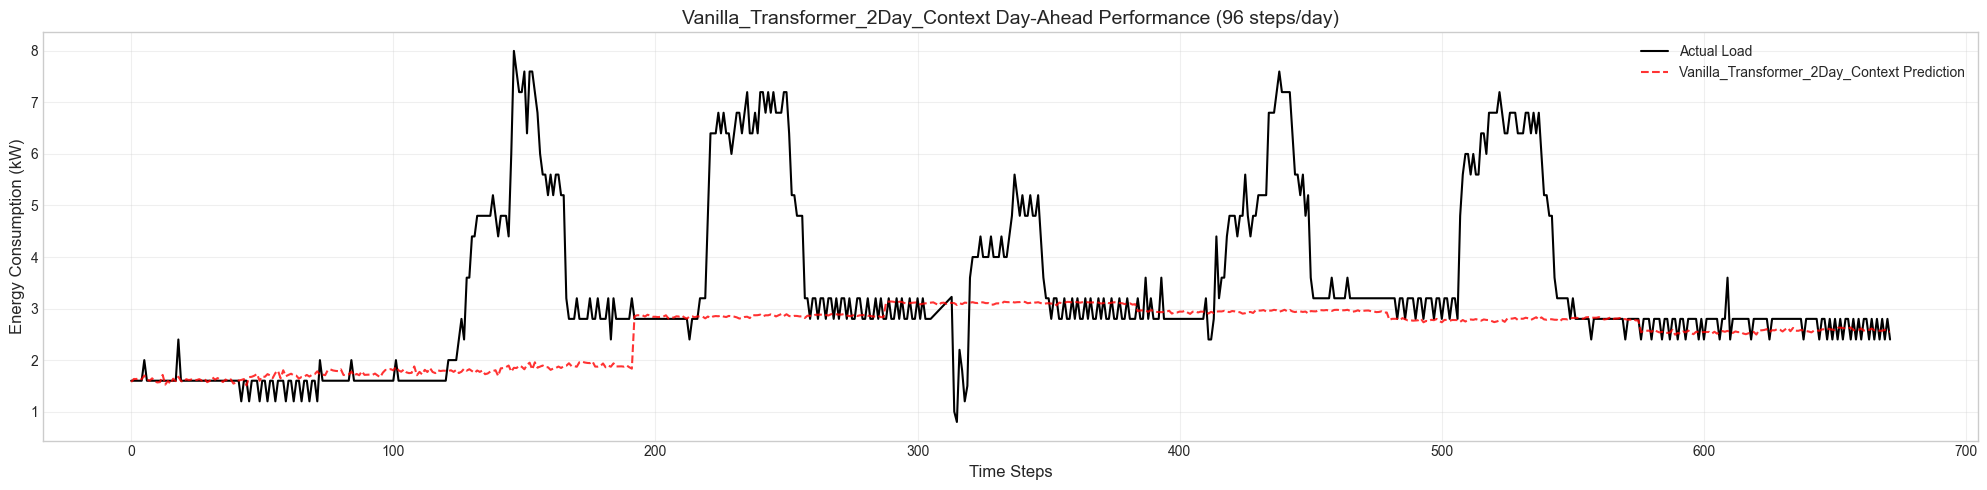

In [19]:
# Vanila Transformer experiments
print("Generating 192-step (2-Day) matrices for deep context testing")
SEQ_LENGTH_192 = 192
HORIZON_STEPS = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

# Using the already scaled dataframe (df_dl_scaled) to prevent scaler leakage
X_train_192, y_train_192 = create_multivariate_sequences(df_dl_scaled.iloc[:train_idx].values, dl_target_idx, SEQ_LENGTH_192, HORIZON_STEPS)
X_val_192, y_val_192     = create_multivariate_sequences(df_dl_scaled.iloc[train_idx:val_idx].values, dl_target_idx, SEQ_LENGTH_192, HORIZON_STEPS)
X_test_192, y_test_192   = create_multivariate_sequences(df_dl_scaled.iloc[val_idx:].values, dl_target_idx, SEQ_LENGTH_192, HORIZON_STEPS)

print(f"1-Day Test Targets (y): {y_test.shape[0]}")
print(f"2-Day Test Targets (y): {y_test_192.shape[0]} (Shorter due to warmup)")

transformer_experiments = [
    {
        "name": "Vanilla_Transformer_1Day_Context",
        "X_train": X_train_3d, "y_train": y_train,
        "X_val": X_val_3d, "y_val": y_val,
        "X_test": X_test_3d, "y_test": y_test,
        "seq_len": 96
    },
    {
        "name": "Vanilla_Transformer_2Day_Context",
        "X_train": X_train_192, "y_train": y_train_192,
        "X_val": X_val_192, "y_val": y_val_192,
        "X_test": X_test_192, "y_test": y_test_192,
        "seq_len": 192
    }
]

epochs = config.TRAINING_PARAMS["epochs"]
batch_size = config.TRAINING_PARAMS["batch_size"]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for exp in transformer_experiments:
    exp_name = exp["name"]
    print(f"\nRunning: {exp_name} (Sequence: {exp['seq_len']})")
    
    # Train or Load Model
    results = run_vanilla_transformer(
        X_train=exp["X_train"], y_train=exp["y_train"], 
        X_val=exp["X_val"], y_val=exp["y_val"], 
        X_test=exp["X_test"], y_test=exp["y_test"], 
        horizon_name=config.ACTIVE_HORIZON, 
        horizon=horizon_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        random_state=config.RANDOM_SEED, 
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH # Professor Mode
    )
    
    # Calculate Metrics (Using the specific y_test and y_train for this sequence length)
    metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        execution_time=results['execution_time'], 
        horizon=horizon_val, 
        y_train=exp["y_train"] 
    )
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results, 
        model_name=exp_name, 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results['y_test_real'], 
        horizon=horizon_val
    )
    
    horizon_metrics.append(metrics)
    print(f"{exp_name} added to leaderboard! (MASE: {metrics['MASE']:.3f})")
    
    # Plot the 7-day trajectory
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        horizon=horizon_val,
        num_steps=horizon_val * 7 
    )


Running: PatchTST_1Day_2Hr_Patches (Sequence: 96 | Patch: 8)

RUNNING PATCHTST (15_min) | Horizon: 96
Training PatchTST for 96 steps
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 97s 82ms/step - loss: 0.0264 - val_loss: 0.0097 - learning_rate: 5.0000e-04
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 102s 88ms/step - loss: 0.0214 - val_loss: 0.0096 - learning_rate: 5.0000e-04
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 103s 88ms/step - loss: 0.0210 - val_loss: 0.0096 - learning_rate: 5.0000e-04
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 106s 91ms/step - loss: 0.0207 - val_loss: 0.0093 - learning_rate: 5.0000e-04
Epoch 5/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 105s 91ms/step - loss: 0.0205 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 103s 89ms/step - loss: 0.0203 - val_loss: 0.0094 - learning_rate: 5.0000e-04
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 103s 89ms/step - loss: 0.0202 - val_loss: 0.0094 - learning_rate: 5.0000e-04
Epoch 8/50
1159/1159 ━━━━━━━━━━━━━

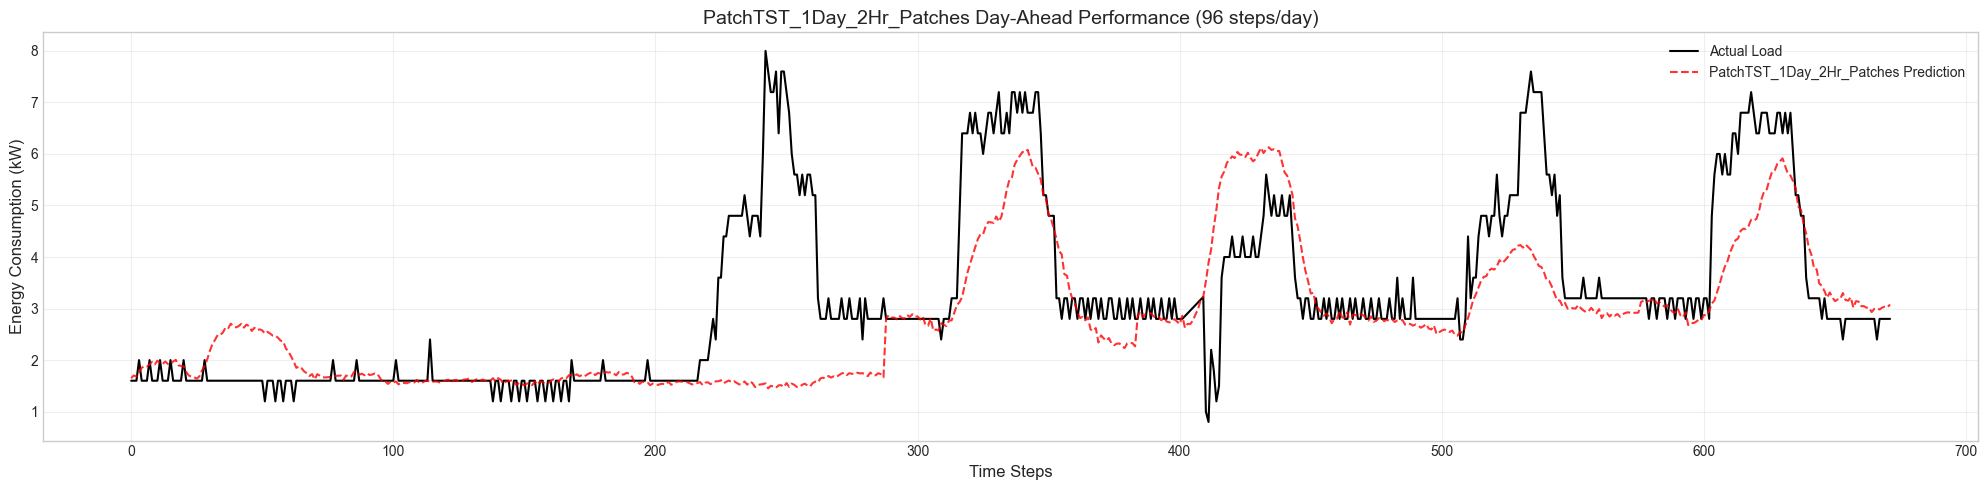


Running: PatchTST_2Day_2Hr_Patches (Sequence: 192 | Patch: 8)

RUNNING PATCHTST (15_min) | Horizon: 96
Training PatchTST for 96 steps
Epoch 1/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 145s 124ms/step - loss: 0.0269 - val_loss: 0.0096 - learning_rate: 5.0000e-04
Epoch 2/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 154s 133ms/step - loss: 0.0209 - val_loss: 0.0107 - learning_rate: 5.0000e-04
Epoch 3/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 151s 131ms/step - loss: 0.0204 - val_loss: 0.0107 - learning_rate: 5.0000e-04
Epoch 4/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 147s 127ms/step - loss: 0.0201 - val_loss: 0.0108 - learning_rate: 5.0000e-04
Epoch 5/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 146s 126ms/step - loss: 0.0198 - val_loss: 0.0107 - learning_rate: 5.0000e-04
Epoch 6/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 148s 128ms/step - loss: 0.0196 - val_loss: 0.0122 - learning_rate: 5.0000e-04
Epoch 7/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 147s 127ms/step - loss: 0.0195 - val_loss: 0.0114 - learning_rate: 5.0000e-04
Epoch 8/50
1156/1156 ━━━━

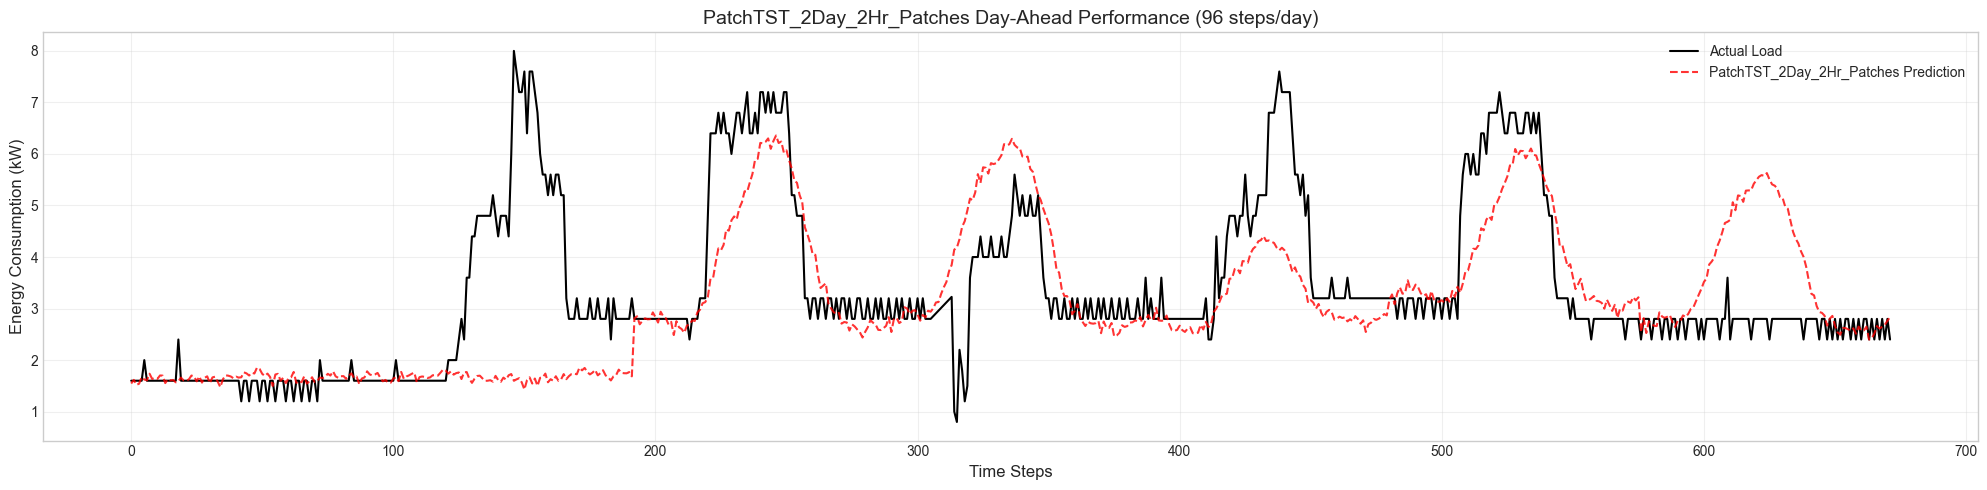


Running: PatchTST_2Day_4Hr_Patches (Sequence: 192 | Patch: 16)

RUNNING PATCHTST (15_min) | Horizon: 96
Training PatchTST for 96 steps
Epoch 1/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 99s 84ms/step - loss: 0.0270 - val_loss: 0.0099 - learning_rate: 5.0000e-04
Epoch 2/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 110s 95ms/step - loss: 0.0211 - val_loss: 0.0096 - learning_rate: 5.0000e-04
Epoch 3/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 102s 89ms/step - loss: 0.0206 - val_loss: 0.0097 - learning_rate: 5.0000e-04
Epoch 4/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 114s 99ms/step - loss: 0.0202 - val_loss: 0.0104 - learning_rate: 5.0000e-04
Epoch 5/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 107s 92ms/step - loss: 0.0200 - val_loss: 0.0110 - learning_rate: 5.0000e-04
Epoch 6/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 115s 99ms/step - loss: 0.0199 - val_loss: 0.0111 - learning_rate: 5.0000e-04
Epoch 7/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 108s 94ms/step - loss: 0.0197 - val_loss: 0.0109 - learning_rate: 5.0000e-04
Epoch 8/50
1156/1156 ━━━━━━━━━━━

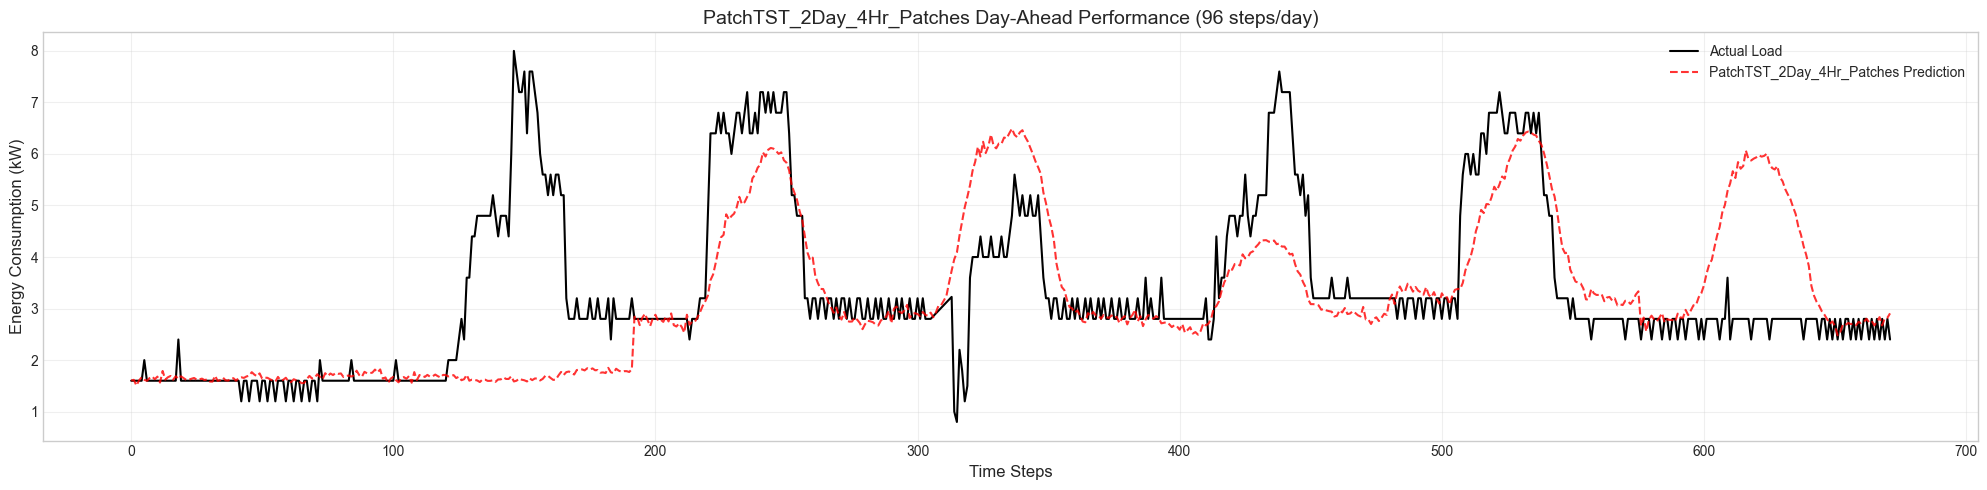

In [20]:
# PatchTST experiments

patch_experiments = [
    {
        "name": "PatchTST_1Day_2Hr_Patches",
        "X_train": X_train_3d, "y_train": y_train,
        "X_val": X_val_3d, "y_val": y_val,
        "X_test": X_test_3d, "y_test": y_test,
        "seq_len": 96, "patch_len": 8, "stride": 8
    },
    {
        "name": "PatchTST_2Day_2Hr_Patches",
        "X_train": X_train_192, "y_train": y_train_192,
        "X_val": X_val_192, "y_val": y_val_192,
        "X_test": X_test_192, "y_test": y_test_192,
        "seq_len": 192, "patch_len": 8, "stride": 8
    },
    {
        "name": "PatchTST_2Day_4Hr_Patches",
        "X_train": X_train_192, "y_train": y_train_192,
        "X_val": X_val_192, "y_val": y_val_192,
        "X_test": X_test_192, "y_test": y_test_192,
        "seq_len": 192, "patch_len": 16, "stride": 16
    }
]

epochs = config.TRAINING_PARAMS["epochs"]
batch_size = config.TRAINING_PARAMS["batch_size"]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for exp in patch_experiments:
    exp_name = exp["name"]
    print(f"\nRunning: {exp_name} (Sequence: {exp['seq_len']} | Patch: {exp['patch_len']})")
    
    # Train or Load Model
    results = run_keras_patchtst(
        X_train=exp["X_train"], y_train=exp["y_train"], 
        X_val=exp["X_val"], y_val=exp["y_val"], 
        X_test=exp["X_test"], y_test=exp["y_test"], 
        horizon_name=config.ACTIVE_HORIZON, 
        horizon=horizon_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        patch_len=exp["patch_len"], 
        stride=exp["stride"], 
        target_idx=dl_target_idx, 
        random_state=config.RANDOM_SEED, 
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH # Professor Mode Check
    )
    
    # Calculate Metrics (Using sequence-specific target arrays!)
    metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        execution_time=results['execution_time'], 
        horizon=horizon_val, 
        y_train=exp["y_train"]
    )
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results, 
        model_name=exp_name, 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results['y_test_real'], 
        horizon=horizon_val
    )
    
    horizon_metrics.append(metrics)
    print(f"{exp_name} added to leaderboard! (MASE: {metrics['MASE']:.3f})")
    
    # Plot the 7-day trajectory
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        horizon=horizon_val,
        num_steps=horizon_val * 7 
    )

### **Foundation Models (Chronos and Chronos2)**


 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-small) | Horizon: 96
Loading amazon/chronos-t5-small


`torch_dtype` is deprecated! Use `dtype` instead!
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


Slicing sliding windows for test set...
Running batch inference (Batch Size: 32)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

Inference successfully cached to ../results/15_min/amazon_chronos-t5-small\predictions.npz


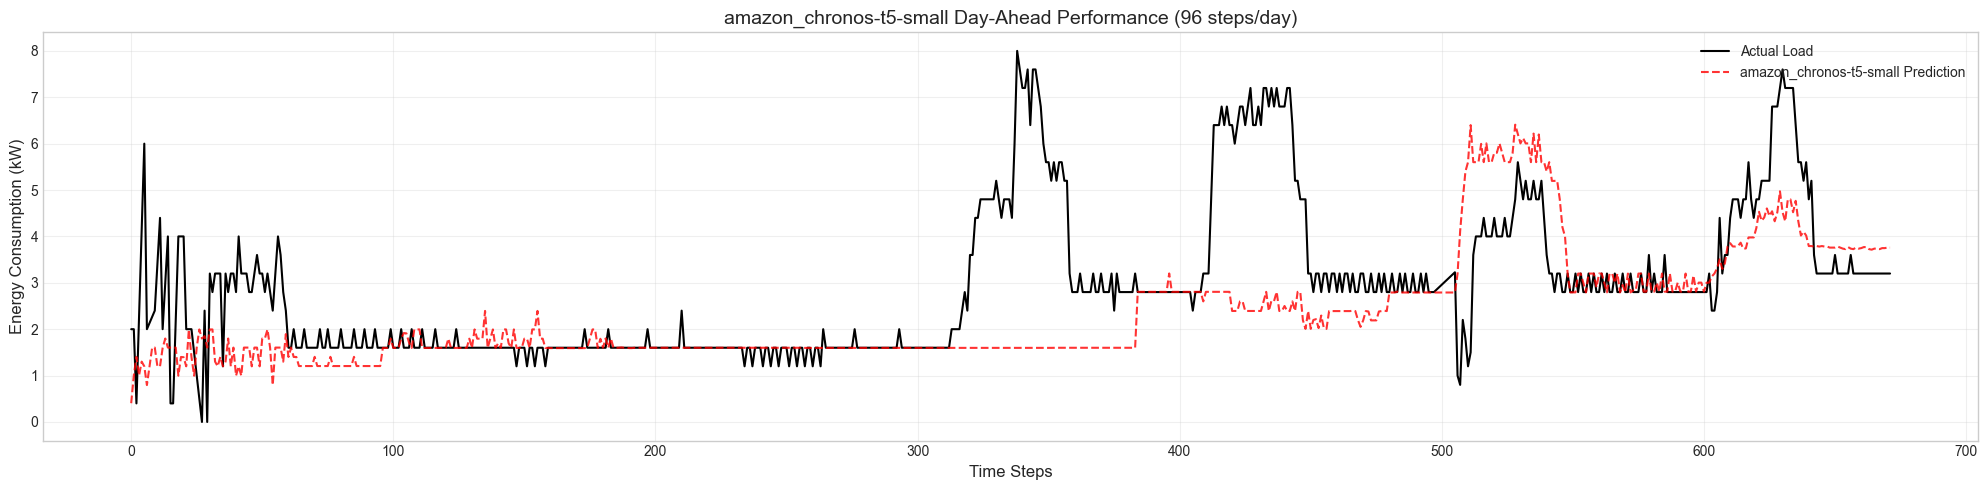

amazon_chronos-t5-small artifacts successfully saved to ../results/15_min/amazon_chronos-t5-small/

 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-base) | Horizon: 96
Loading amazon/chronos-t5-base


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


Slicing sliding windows for test set...
Running batch inference (Batch Size: 16)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

Inference successfully cached to ../results/15_min/amazon_chronos-t5-base\predictions.npz


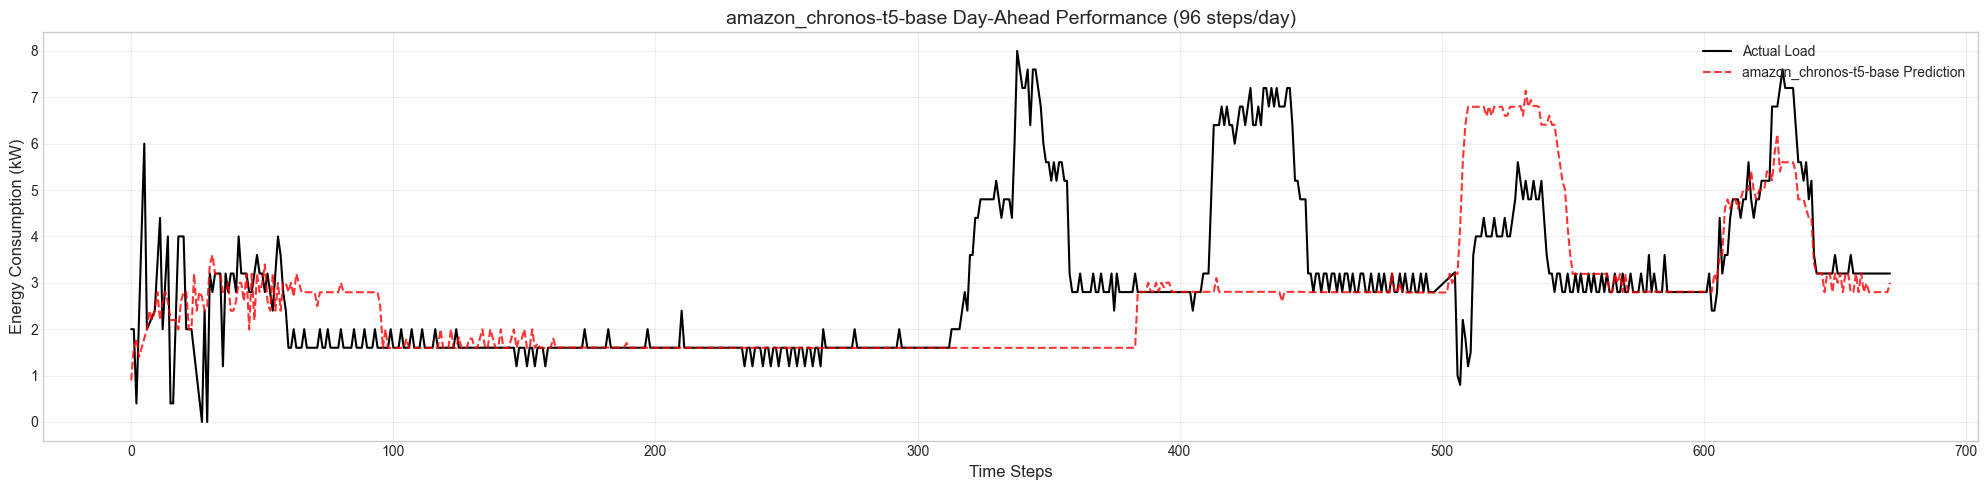

amazon_chronos-t5-base artifacts successfully saved to ../results/15_min/amazon_chronos-t5-base/

 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-large) | Horizon: 96
Loading amazon/chronos-t5-large
Slicing sliding windows for test set...


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


Running batch inference (Batch Size: 4)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

In [ ]:
chronos_models = [
    {"name": "amazon/chronos-t5-small", "batch_size": 32},
    {"name": "amazon/chronos-t5-base",  "batch_size": 16},
    {"name": config.CHRONOS_CONFIG["model_name"], "batch_size": config.CHRONOS_CONFIG["batch_size"]} 
]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for model_config in chronos_models:
    model_name = model_config["name"]
    batch_size = model_config["batch_size"]
    
    results_chronos = run_chronos_univariate(
        df=df_master, # Unscaled dataframe
        target_col=TARGET_COL,
        horizon_name=config.ACTIVE_HORIZON,
        model_name=model_name, 
        batch_size=batch_size, 
        context_length=512, # 5.3 days of context
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Save artifacts using the existing pipeline
    save_experiment_results(
        results_dict=results_chronos, 
        model_name=results_chronos["model"], 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results_chronos['y_test_real'], 
        horizon=horizon_val
    )
    
    horizon_metrics.append(results_chronos["metrics"])

In [ ]:
# Explicitly Map the Features
weather_cols = ["temperature_v1", "relative_humidity_v1", "wind_speed_v1", "clouds_v1"]
market_cols = ["energy_generation", "smp"]

time_cols = [
    "hour_sin", "hour_cos", "day_sin", "day_cos", "month_sin", "month_cos", 
    "is_holiday", "is_weekend", "is_non_working_day", "energy_flow_quarter"
]

lag_cols = [
    "energy_consumption_lag_1w", "energy_generation_lag_1w", 
    "smp_lag_1w", "temperature_v1_lag_1w"
]

# Create the Datasets for Chronos2_Multivariate experiments
df_oracle = df_master.copy()
df_degraded = df_master.copy()

total_rows = len(df_master)
train_val_idx = int(total_rows * (config.TRAIN_SPLIT + config.VAL_SPLIT))

np.random.seed(config.RANDOM_SEED)

# Apply Realistic Forecast Error (Noise) to the Test Horizon
for col in weather_cols + market_cols:
    if col == "temperature_v1":
        noise = np.random.normal(0.0, 2.0, size=(total_rows - train_val_idx)) # +/- 2 degrees
    elif col == "relative_humidity_v1" or col == "clouds_v1":
        noise = np.random.normal(0.0, 5.0, size=(total_rows - train_val_idx)) # +/- 5%
    elif col == "wind_speed_v1":
        noise = np.random.normal(0.0, 1.5, size=(total_rows - train_val_idx)) # +/- 1.5 m/s
    elif col == "energy_generation":
        noise = np.random.normal(0.0, df_master[col].std() * 0.1, size=(total_rows - train_val_idx)) # 10% error
    elif col == "smp":
        noise = np.random.normal(0.0, df_master[col].std() * 0.1, size=(total_rows - train_val_idx)) # 10% error
        
    df_degraded.iloc[train_val_idx:, df_degraded.columns.get_loc(col)] += noise

In [ ]:
# Chronos2 Multivariate experiments
# The covariates we explicitly pass into the future context
base_deterministic_cols = time_cols + lag_cols
uncertain_forecast_cols = weather_cols + market_cols

# Define the 3 Experiments
chronos2_experiments = [
    {
        "exp_name": "Chronos2_Multivariate_Oracle",
        "df": df_oracle,
        "covariates": base_deterministic_cols + uncertain_forecast_cols 
    },
    {
        "exp_name": "Chronos2_Multivariate_Realistic",
        "df": df_degraded,
        "covariates": base_deterministic_cols + uncertain_forecast_cols
    },
    {
        "exp_name": "Chronos2_Multivariate_Blind",
        "df": df_master,
        # Notice we entirely drop the weather/market features here!
        "covariates": base_deterministic_cols 
    }
]

horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for exp in chronos2_experiments:
    # run your updated v2 pipeline function
    results = run_chronos2_multivariate_v2(
        df=exp["df"],
        deterministic_covariates=exp["covariates"],
        experiment_name=exp["exp_name"],
        target_col=TARGET_COL,
        horizon_name=config.ACTIVE_HORIZON,
        model_name=config.CHRONOS_2_CONFIG["model_name"],
        batch_size=config.CHRONOS_2_CONFIG["batch_size"],
        context_length=config.CHRONOS_2_CONFIG["context_length"],
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Extract baseline training values for MASE calculation
    y_train_raw = df_master[TARGET_COL].values[:int(len(df_master) * (config.TRAIN_SPLIT + config.VAL_SPLIT))]
    
    # Calculate metrics
    metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp['exp_name'], 
        execution_time=results['execution_time'], 
        horizon=horizon_val, 
        y_train=y_train_raw
    )
    results['metrics'] = metrics
    
    # Save standard experiment metadata metrics
    save_experiment_results(
        results_dict=results, 
        model_name=exp['exp_name'], 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results['y_test_real'], 
        horizon=horizon_val
    )
    
    horizon_metrics.append(metrics)
    print(f"{exp['exp_name']} added to leaderboard! (MASE: {metrics['MASE']:.3f})")
    
    # Plot performance trajectory
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=f"{exp['exp_name']} (7-Day View)", 
        horizon=horizon_val,
        num_steps=horizon_val * 7 
    )

**Experiment 1:** The Oracle Model (Perfect Foresight)
What we are doing: We are passing the df_oracle dataset, which contains the 100% accurate, actual recorded weather and market data for the future horizon.

Why we are doing it: This establishes the Absolute Mathematical Ceiling of your foundation model. You are asking: "If a psychic gave me a flawless weather and market forecast, how accurate could this model possibly be?" This proves the model's capacity to learn thermodynamics and market behavior under perfect conditions.

**Experiment 2:** The Realistic Model (Degraded Forecast)
What we are doing: We are passing the df_degraded dataset. We injected realistic Gaussian noise into the test horizon (e.g., simulating a meteorologist being off by 2°C or 5% humidity, and a grid forecast being off by 10%).

Why we are doing it: This simulates Real-World Deployment. It answers a critical engineering question: Is the foundation model robust to noisy data? If a minor error in the weather forecast causes the LLM's predictions to completely collapse, the model is too fragile for real-world grid operations.

**Experiment 3:** The Blind Model (Zero Exogenous Data)
What we are doing: We are completely hiding the weather and market data from the future context, providing only deterministic time features (like the hour of the day and 1-week lags).

Why we are doing it: This establishes the Autoregressive Baseline. By comparing this to the Oracle and Realistic models, you isolate the exact mathematical value of adding weather. If the Blind model scores a MASE of 0.80 and the Realistic model scores a MASE of 0.78, you have proven that complex weather integrations only improve the model by a fractional margin—a massive insight for future software architecture.

### **Hourly Error Heatmap and Final Results**

In [ ]:
# 1. Compile and Display the Final Results Table
results_df = pd.DataFrame(horizon_metrics)
results_df = results_df.sort_values(by="MASE").reset_index(drop=True)

# Format for clean display
display_df = results_df.copy()
for col in ['MSE', 'RMSE', 'MAE', 'MAPE', 'sMAPE', 'MASE', 'R2']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")
display(display_df)

# 2. Hourly Error Heatmap (Using the Best Model)
print("\n📊 GENERATING HOURLY ERROR HEATMAP...")
best_model_name = results_df.iloc[0]['Model']
print(f"Analyzing champion model: {best_model_name}")

# NOTE: Load your champion model's predictions here! 
# Example assuming you saved your champion's predictions in a variable `champion_preds` 
# and real values in `champion_real`:
# champion_preds = results_chronos['predictions'] 
# champion_real = results_chronos['y_test_real']

def plot_hourly_error_heatmap(y_true, y_pred, model_name, horizon_steps=96):
    """Plots a heatmap of Absolute Error by Day and Hour."""
    # Flatten the first 7 days (7 days * 96 steps = 672 steps)
    limit = horizon_steps * 7
    if len(y_true.flatten()) < limit:
        limit = len(y_true.flatten())
        
    true_flat = y_true.flatten()[:limit]
    pred_flat = y_pred.flatten()[:limit]
    
    absolute_errors = np.abs(true_flat - pred_flat)
    
    # Reshape into (Days, 15-min intervals)
    # 96 intervals = 24 hours. We will group by hour for readability.
    days = limit // horizon_steps
    errors_reshaped = absolute_errors.reshape(days, horizon_steps)
    
    # Average the 15-minute intervals into Hourly intervals (4 steps per hour)
    hourly_errors = errors_reshaped.reshape(days, 24, 4).mean(axis=2)
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(hourly_errors, cmap="YlOrRd", annot=False, 
                cbar_kws={'label': 'Mean Absolute Error (kW)'})
    plt.title(f"Hourly Absolute Error Heatmap (1st Week) - {model_name}", fontsize=14)
    plt.xlabel("Hour of Day (0-23)", fontsize=12)
    plt.ylabel("Day Index", fontsize=12)
    plt.tight_layout()
    plt.show()

# plot_hourly_error_heatmap(champion_real, champion_preds, best_model_name, horizon_steps=config.HORIZON_STEPS[config.ACTIVE_HORIZON])

### **Visualizing Probabilistic Forecasts (Uncertainty Bounds)**
This cell evaluates the Chronos Foundation Model's confidence by plotting an 80% Prediction Interval. Instead of a single point forecast, it extracts the 10th (lower bound), 50th (median forecast), and 90th (upper bound) percentiles from the model's output distribution. The resulting shaded region visually demonstrates the model's uncertainty, distinguishing between periods of high certainty (e.g., stable nighttime baseloads) and high volatility (e.g., afternoon HVAC spikes and solar generation).

1. Plot a standard Tuesday (to show normal bounds).
2. Plot a Sunday (to show how the bounds handle a weekend drop).
3. Plot a volatile day with heavy cloud cover (to show the bounds expanding heavily due to uncertainty).

In [ ]:
def plot_probabilistic_forecast(y_true, y_pred_median, lower_bound, upper_bound, model_name, num_steps=384):
    """
    Plots the median prediction alongside the 10th and 90th percentile bounds.
    num_steps=384 shows exactly 4 days of 15-minute intervals.
    """
    plt.figure(figsize=(15, 6))
    
    # Flatten arrays
    true_flat = y_true.flatten()[:num_steps]
    median_flat = y_pred_median.flatten()[:num_steps]
    lower_flat = lower_bound.flatten()[:num_steps]
    upper_flat = upper_bound.flatten()[:num_steps]
    
    x_axis = np.arange(num_steps)
    
    # Plot Actual vs Median
    plt.plot(x_axis, true_flat, label="Actual Load", color="black", linewidth=2)
    plt.plot(x_axis, median_flat, label="Median Forecast (P50)", color="blue", linestyle="--", linewidth=2)
    
    # Fill the uncertainty bounds (P10 to P90)
    plt.fill_between(x_axis, lower_flat, upper_flat, color='blue', alpha=0.2, 
                     label="80% Confidence Interval (P10 - P90)")
    
    plt.title(f"Probabilistic Forecast Bounds - {model_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Time Steps (15-min intervals)", fontsize=12)
    plt.ylabel("Energy Consumption", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage (assuming results from Chronos2 Oracle):
# plot_probabilistic_forecast(results['y_test_real'], results['predictions'], results['lower_bounds'], results['upper_bounds'], "Chronos-2 Oracle")

### **Global Feature importance and Graphs**

In [ ]:
def plot_tree_feature_importance(trained_model, feature_names, top_n=15, model_title="XGBoost"):
    """Extracts and plots the top N feature importances from a trained tree model."""
    importances = trained_model.feature_importances_
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1][:top_n]
    top_features = [feature_names[i] for i in indices]
    top_importances = importances[indices]
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_importances, y=top_features, palette="viridis")
    plt.title(f"Global Feature Importance (Top {top_n}) - {model_title}", fontsize=14)
    plt.xlabel("Relative Importance Score", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_tree_feature_importance(xgboost_model_object, X_train.columns.tolist(), model_title="XGBoost Baseline")

### **ACF/PACF (The "Memory" Test) & Shapiro-Wilk ("Normality" Test)**

In [ ]:
def analyze_residuals(y_true, y_pred, model_name):
    # Flatten arrays
    true_flat = y_true.flatten()
    pred_flat = y_pred.flatten()
    
    # Calculate Residuals (Errors)
    residuals = true_flat - pred_flat
    
    print("\n" + "="*50)
    print(f"🔬 RESIDUAL DIAGNOSTICS: {model_name}")
    print("="*50)
    
    # 1. Systematic Bias (Mean Error)
    mean_error = np.mean(residuals)
    print(f"1. Systematic Bias (Mean Error): {mean_error:.4f}")
    if mean_error > 0:
        print("   -> The model systematically UNDER-predicts the load.")
    else:
        print("   -> The model systematically OVER-predicts the load.")
        
    # 2. Normality Test (Shapiro-Wilk)
    # Note: Shapiro-Wilk is overly sensitive on large datasets, so we sample 4000 points.
    sample_size = min(4000, len(residuals))
    stat, p_value = stats.shapiro(np.random.choice(residuals, sample_size, replace=False))
    print(f"\n2. Shapiro-Wilk Normality Test (Sampled n={sample_size}):")
    print(f"   -> Test Statistic: {stat:.4f}, p-value: {p_value:.4e}")
    if p_value > 0.05:
        print("   -> Fail to reject null: Errors ARE normally distributed.")
    else:
        print("   -> Reject null: Errors are NOT perfectly normally distributed (Common in power load).")

    # 3. Visual Diagnostics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot A: Residual Distribution
    sns.histplot(residuals, kde=True, ax=axes[0], color='purple')
    axes[0].set_title("Residual Distribution")
    axes[0].set_xlabel("Error (Actual - Predicted)")
    axes[0].axvline(0, color='black', linestyle='--')
    
    # Plot B: Autocorrelation (ACF)
    sm.graphics.tsa.plot_acf(residuals[:1000], lags=96, ax=axes[1], title="ACF (Autocorrelation of Errors)")
    
    # Plot C: Partial Autocorrelation (PACF)
    sm.graphics.tsa.plot_pacf(residuals[:1000], lags=96, ax=axes[2], title="PACF (Partial Autocorr of Errors)")
    
    plt.tight_layout()
    plt.show()

# Example usage:
# analyze_residuals(champion_real, champion_preds, best_model_name)

### **Statistical Significance (Paired with T-test)**

In [ ]:
evaluate_statistical_significance(
    y_true=y_test_real, 
    y_pred_a=xgboost_preds, 
    y_pred_b=chronos2_oracle_preds, 
    model_a_name="XGBoost Baseline", 
    model_b_name="Chronos-2 Oracle"
)